# Set-up

In [1]:
import os
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns

import seqpro as sp

from tqdm.auto import tqdm

from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.utils import random_one_hot
from tangermeme.plot import plot_logo

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [3]:
os.chdir('/cellar/users/aklie/projects/igvf/ChromBetaNet')

In [4]:
path_model = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/SC.beta/fold_0/chrombpnet/0.8/models/chrombpnet_nobias.h5"

path_out = "results/9_sequence_design"

# Auxiliary data

In [5]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg19/hg19.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [6]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg19/hg19.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load model

In [7]:
model = BPNet.from_chrombpnet(path_model).cuda().eval()

In [8]:
count_wrapper = CountWrapper(model).cuda().eval()

# Load sequences

In [9]:
# NK6X-1 enhancer
original_seq = "AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATgaggtgagggcaagatggaggtggggtggaggCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCAGTAATCATTATTTAGAACATGATTAAATATGTCTGCACCTATTGACTCTGCCTATGATTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGATGTAATTAATTATAGATGGTGGTGTCAGGTCATTGGTGAAAACAATCTGAGGAGAACAAGGGCTCTGTTTTTTTCATGACAGATGCAGGGGGGTGGGGGGCTGAGTTGAGGGAATTCCAGGGGAACTTTTTCACGTGTGAATGGCGGCTGGGATCTCAATTTGCATGTTGTCTTTCTCTTGTTCAGCCTTCGTTTAGAAATTGAAATAACTTGTTAAGCAAAGGGGAAGGGAGCACATGGTTGCCAGGAGGACACCTGGGACTTGGGCGGGTGAGTAGGTAAAGAACCAGCTGCTCCCTAACACAGGGGAGCGTGGCACCATCATTTACCGCTTCATAAAATTAAATGTTTTCCAAATTAAATCAGTAGACAGTGTGCAGGAGGCCTACTATCTCTAATAACAATTTTTCAATCAATATGAGGGGCCTTGCCAATATGAAATCTGAGCTGAGGAAGTTAGGATGGGCTGGGGAGGGAGTGTCAGAGGATGGCACAGGCGAGGAGGTGGAAACAGGGTTTGAGTACCGAAGCTTTCAATCAAACCAAAGGTTTAAAAAATATAGATATATATTCATGGTGGATTCGCCACCACTGTGAGTCTATTCCCTGTAGATTTTTCTCTTAACTGATAATTCGGTCAGTCACATTCCTCAGAGGGGGGTCACAGGTCACCCCAGCCCCTGTCAGGCCTCAGAGAAACCATTTCCATTTTAATGCCACAGCTATAATCTATCAAAGATGTGATGTACAAGATACAATGAATTTAAGTGGTCTTCATATATCACTGAGCTTTCATGCCTTCACCTGGGTAATAGTCTGAATTACTCTCCCTACCTCACAATCTGTCACCCCCAGTAAAATAACTGCCATGCCGGTGTTAATGACAGATTTGTCCAAATTGGGGCCACAGTAGCCAAAGTCATTCTACATCATAAACTTTAGCATTTAGTGCTTAGCCTGGAAAGGGCCCATAGCTTAAAATACTTCTGTAAATAATTCTGTGGAGAGGCTCTACTCATGTTTTTATTTATAAGAGCTAAAATAAATCTAGCTGGGGCTGCACACAACCTGCCTTCTCCATTTCTCTGTATCTAGACCTCTCTCTCTCAAACCTGT".upper()
revcomp_original_seq = sp.reverse_complement(original_seq, sp.DNA)
len(original_seq), len(revcomp_original_seq)

(2114, 2114)

In [10]:
# Turn into tensor, 3 options

# ISM taking into account both forward and reverse strand
#X_forward = torch.tensor(np.expand_dims(sp.ohe(original_seq, alphabet=sp.DNA).transpose(), axis=0), dtype=torch.float32)
#X_reverse = torch.tensor(np.expand_dims(sp.ohe(revcomp_original_seq, alphabet=sp.DNA).transpose(), axis=0), dtype=torch.float32)
#X = torch.cat([X_forward, X_reverse], axis=0).cuda()

# Just forward strand
X = torch.tensor(np.expand_dims(sp.ohe(original_seq, alphabet=sp.DNA).transpose(), axis=0), dtype=torch.float32)

# Random
#X = torch.tensor(random_one_hot((1,4,2114), random_state=1234), dtype=torch.float32).cuda()

#X.shape

# ISM

In [11]:
from bpnetlite.bpnet import CountWrapper
from tangermeme.ism import saturation_mutagenesis, _edit_distance_one

In [12]:
# Define model and ism params
seq_len = 2114
target_len = 1000
ism_window = 500

In [13]:
# Seq limits
seq_center = 2114 // 2
seq_start = seq_center - ism_window // 2
seq_end = seq_center + ism_window // 2
seq_start, seq_end

(807, 1307)

In [14]:
# Target limits
target_center = 1000 // 2
target_start = target_center - ism_window // 2
target_end = target_center + ism_window // 2
target_start, target_end

(250, 750)

In [15]:
# Run ISM
y0, y_hat = saturation_mutagenesis(
    count_wrapper,
    X,
    start=seq_start,
    end=seq_end,
    raw_outputs=True,
    verbose=True,
)

100%|██████████| 63/63 [00:03<00:00, 17.38it/s]


In [16]:
# Optional mask
msk = (torch.abs(y_hat[:, :, :, 0] - y0[:, None, None, 0]) < 5e-4)
msk = msk.float()

In [17]:
attr = y_hat[:, :, :, 0] - y0[:, None, None, 0]
#attr = torch.exp(y_hat[:, :, :, 0]) - torch.exp(y0[:, None, None, 0])
attr = attr.numpy()

In [18]:
# Make all msk positions NaN
y_hat_np = y_hat[:, :, :, 0].cpu().numpy()
y_hat_np_msk = y_hat_np.copy()
y_hat_np_msk[msk.bool()] = np.nan

In [19]:
# Make a dataframe where x_axis is the position in the sequence and y-axis is forward_pred for y_hat_np[0] and reverse_pred for y_hat_np[1]
pred_df = pd.DataFrame(
    data=y_hat_np_msk.reshape(y_hat_np_msk.shape[0], -1).T, 
    columns=['forward_pred', 'reverse_pred'] if X.shape[0] == 2 else ['forward_pred'],
)
pred_df.isna().sum(axis=0)

forward_pred    512
dtype: int64

In [20]:
# Take the average across the batch
if X.shape[0] == 2:
    attr_mean = np.mean(attr, axis=0)
else:
    attr_mean = attr.squeeze(0)
attr_mean.shape

(4, 500)

In [21]:
k = 1
idx = np.argsort(attr_mean.ravel())[:-k-1:-1]
indices = np.column_stack(np.unravel_index(idx, attr_mean.shape))[0]
indices

array([  0, 225])

In [22]:
attr[0, indices[0], indices[1]]

0.49296474

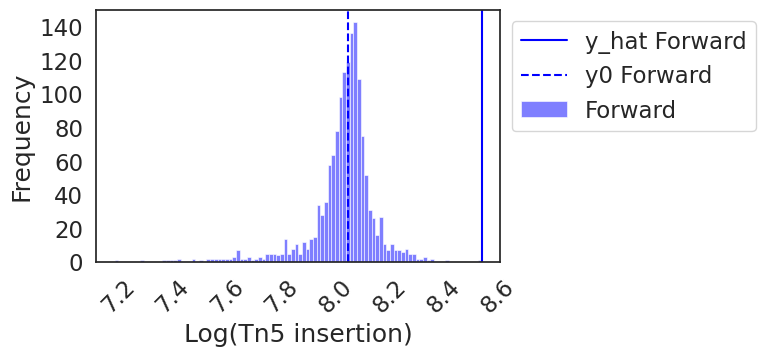

In [23]:
# Plot histograms of the forward predictions and the reverse predictions on same axis
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    y_hat_forward = y_hat_np[0, indices[0], indices[1]]
    ax.axvline(y_hat_forward, color='blue', linestyle='-', label='y_hat Forward')
    sns.histplot(data=pred_df, x='forward_pred', color='blue', label='Forward', bins=100, ax=ax, alpha=0.5)
    ax.axvline(y0[0], color='blue', linestyle='--', label='y0 Forward')


    # Plot reverse
    if X.shape[0] == 2:
        sns.histplot(data=pred_df, x='reverse_pred', color='red', label='Reverse', bins=100, ax=ax, alpha=0.5)
        ax.axvline(y0[1], color='red', linestyle='--', label='y0 Reverse')
        y_hat_reverse = y_hat_np[1, indices[0], indices[1]]
        ax.axvline(y_hat_reverse, color='red', linestyle='-', label='y_hat Reverse')

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()
    

In [24]:
# edit channel is just indices[0]
# edit position is seq_start + indices[1]
edit_channel = indices[0]
edit_position = seq_start + indices[1]

In [25]:
# copy the tensor
X_ = X.clone()

# zero out the position across the channels
X_[0, :, edit_position] = 0
X_[0, edit_channel, edit_position] = 1

In [26]:
_ = predict(
    count_wrapper,
    X_,
)

In [27]:
# Turn all the above into a function for greedy_ism
def greedy_ism(
    model,
    X,
    seq_len=2114,
    ism_window=500,
    k=1,
    max_iter=10,
    verbose=False,
):
    """
    Perform greedy ISM on a sequence.
    
    Parameters
    ----------
    model : BPNet
        The model to use for prediction.
    X : torch.Tensor
        The input sequence as a one-hot encoded tensor.
    seq_len : int
        The length of the input sequence.
    target_len : int
        The length of the target sequence.
    ism_window : int
        The window size for ISM.
    k : int
        The number of top positions to select.
    max_iter : int
        The maximum number of iterations to perform.
    verbose : bool
        Whether to print progress messages.

    Returns
    -------
    X_ : torch.Tensor
        The modified sequence after greedy ISM.
    """

    # Define seq limits
    seq_center = seq_len // 2
    seq_start = seq_center - ism_window // 2
    seq_end = seq_center + ism_window // 2

    # Initial copy of the tensor
    X_ = X.clone()

    # Get the original prediction
    y0 = predict(count_wrapper, X_).cpu().numpy()[0]
    print(f"Iteration 0/{max_iter} - y_hat: {y0[0]:.3f}")

    # Run ISM across rounds
    for i in range(max_iter):
        
        if verbose:
            print(f"Iteration {i+1}/{max_iter}", end="")

        # Run ISM
        y0, y_hat = saturation_mutagenesis(
            model,
            X_,
            start=seq_start,
            end=seq_end,
            raw_outputs=True,
            verbose=False,
        )

        # Get the updates
        attr = y_hat[:, :, :, 0] - y0[:, None, None, 0]
        attr = attr.numpy()

        # Take the average across the batch
        if X.shape[0] == 2:
            attr_mean = np.mean(attr, axis=0)
        else:
            attr_mean = attr.squeeze(0)

        # Get the top k positions
        idx = np.argsort(attr_mean.ravel())[:-k-1:-1]
        indices = np.column_stack(np.unravel_index(idx, attr_mean.shape))[0]

        # if verbose print out the new y_hat value
        if verbose:
            y_hat_np = y_hat[:, :, :, 0].cpu().numpy()
            print(f" - y_hat: {y_hat_np[0, indices[0], indices[1]]:.3f}")

        # Get the edit channel and position
        edit_channel = indices[0]
        edit_position = seq_start + indices[1]
        
        # zero out the position across the channels
        X_[0, :, edit_position] = 0
        X_[0, edit_channel, edit_position] = 1

    return X_

In [28]:
X_greedy = greedy_ism(
    count_wrapper,
    X,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
)

Iteration 0/10 - y_hat: 8.048
Iteration 1/10 - y_hat: 8.541
Iteration 2/10 - y_hat: 8.866
Iteration 3/10 - y_hat: 9.351
Iteration 4/10 - y_hat: 9.717
Iteration 5/10 - y_hat: 10.105
Iteration 6/10 - y_hat: 10.493
Iteration 7/10 - y_hat: 10.732
Iteration 8/10 - y_hat: 10.980
Iteration 9/10 - y_hat: 11.285
Iteration 10/10 - y_hat: 11.558


In [29]:
predict(count_wrapper, X_greedy).cpu().numpy()[0]

array([11.557899], dtype=float32)

# Plot mutations

In [32]:
X_greedy.shape

torch.Size([1, 4, 2114])

In [33]:
mutated_seq = sp.decode_ohe(X_greedy.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
mutated_seq

'AAAGAAATTATAGCATGATGTCTTTCCTTCAAGCTGTAACTTCTTAGTAATTGGCCTTACCTATTGATAGCCAGATGTGAAGGAGAATAGGAGACATTCTATTATTTGCAAAGCACCCAACTATGGTATGCTTAGTCACAAACAAAACATTTCAAGGAGAAGACTCCATTTCTAAGTTAGAAAAAAAATGTACACCTATAAACACTGATTCATTCTCTTCTCTCTGATGACAAACACTAAATTAGTCTATAAATTATGAGTATTATGTTTGTAGAGTACCCCCATGTTCTAACTACTCCACCTCTTTAATCAATTTGCCATTCCAAAATGGAAAATGATTTAGAAAAACCTGTCAAACAGAAGAGAAAGAAAATCTAATCTGGGCAAGTTATTAAGAAATCTGCTTCTTTGAATCTTTAACATTTAAACTGTCCATAGAGATTTAGAAATGAGGTGAGGGCAAGATGGAGGTGGGGTGGAGGCTTGGGGCACAGGGTGGGGGCTGCAAAGAGAGACTAGCTGCATCCCCAGAGCACCGGAGCACCGTCTAGCTTGGAAGAAGAATGGGAAGTTACACGTTGAGAGATAGAGAAAGAAGCAGAGACAGGTGGCAAAAAGAACAAGTATGAAACAGGCAGGAATACAGGAGGAAGACAAAGAAGAACATGAAAAGTGGAGGAAAAAACAATGAGAAGTAGAGAAGGAGTCATGAGAGGAGAAAGGGGGAACCGAGGGAGCCTGCGGGGAAGAATGAAAAGAAGGGAAACTAAGAGAGAAAAAGAACAGCTCCTCCATCATCGGTGCTGCCTTCTTCATCTTCGTCTCTTTTTTTTTTCAGATGGCACACTGACAGAAGATTAATTCAAGTCAGCTGCTGAAAATAATTATTGCATTATGGGAGCATTAATCATTAGCTAGAAAATGATTAACTATGTCTGCACCTGTTGACTCTGCCTATGACTTATGTATTTGTTTAGTCAATAGTCTAATGTAAATGAT

In [34]:
# Find all the differences between the original and mutated sequences, both the change and the position
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(903, 'G', 'T'),
 (913, 'T', 'G'),
 (914, 'T', 'C'),
 (920, 'C', 'A'),
 (929, 'A', 'C'),
 (943, 'A', 'G'),
 (960, 'T', 'C'),
 (1007, 'T', 'G'),
 (1010, 'T', 'C'),
 (1032, 'G', 'A')]

In [35]:
original_seq_onehot = np.expand_dims(sp.ohe(original_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
original_seq_onehot.shape, mutated_seq_onehot.shape

((1, 4, 2114), (1, 4, 2114))

In [36]:
original_profile, original_counts = predict(model, torch.tensor(original_seq_onehot).float().cuda())
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original counts: 3127.501708984375
mutated counts: 104600.0625


In [38]:
original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

((1000,), (1000,))

In [39]:
dtype = torch.float64
count_wrapper = CountWrapper(ControlWrapper(model)).cuda().eval()

In [40]:
# Get attribution scores for the original sequence
X_attr_counts = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(original_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)

100%|██████████| 20/20 [00:28<00:00,  1.42s/it]


In [41]:
# Get attribution scores for the mutated sequence
X_attr_counts_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 27.19it/s]


# Plot

In [42]:
seq_len = 2114
target_len = 1000

In [43]:
chrom = "chr4"
start = 84432784
end = 84434897

In [44]:
window = 500
seq_center = 2114 // 2
plot_center = 1050
offset = plot_center - seq_center
offset

-7

In [45]:
seq_start = seq_center - window // 2
seq_end = seq_center + window // 2
target_start = (target_len // 2 - window // 2) + offset
target_end = (target_len // 2 + window // 2) + offset
ref_start = start + seq_start
ref_end = start + seq_end
seq_start, seq_end, target_start, target_end, ref_start, ref_end

(807, 1307, 243, 743, 84433591, 84434091)

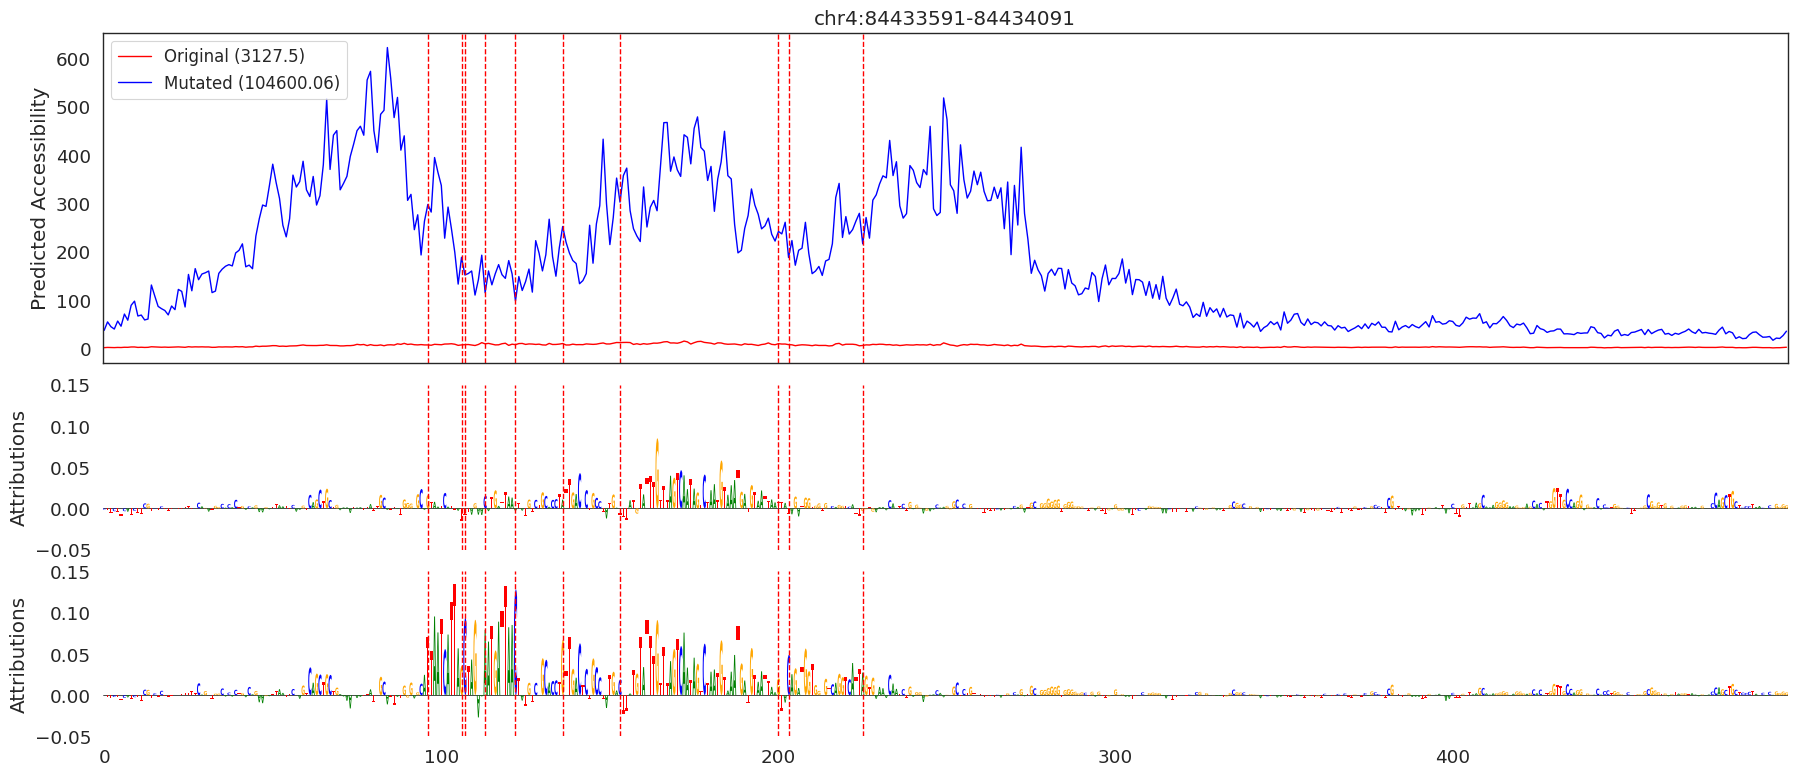

In [46]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, window), original_pred[target_start:target_end], color='r', linewidth=1, label=f"Original ({round(float(original_counts), 2)})")
    axes[0].plot(range(0, window), mutated_pred[target_start:target_end], color='b', linewidth=1, label=f"Mutated ({round(float(mutated_counts), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_counts[0, :, seq_start:seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_counts_mutated[0, :, seq_start:seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - seq_start
        axes[0].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(f"{path_out}/NKX6-1_predicted_FOXA_optimization_{window}.pdf", dpi=300)

In [47]:
from tangermeme.io import read_meme
from tangermeme.tools.fimo import fimo
from tangermeme.plot import plot_pwm

motifs = read_meme("/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/ref/motifs.meme")
motif_names = np.array(list(motifs.keys()))


#motifs = {name: motifs[name] for name in motif_subset}
motif_names = np.array(list(motifs.keys()))
motif_pwms = list(motifs.values())

In [51]:
hits_before = fimo(motifs, X[seq_start:seq_end], return_counts=True, threshold=0.001)
hits_after = fimo(motifs, X_[:seq_start:seq_end], return_counts=True, threshold=0.001) / len(X_)

In [59]:
hits_after

array([ 1.,  2.,  2., ..., 14.,  5.,  2.])

In [52]:
hits_diff = hits_after - hits_before
hits_idxs = hits_diff.argsort()

In [64]:
len(motif_names[hits_idxs])

2178

In [95]:
from tangermeme.seqlet import recursive_seqlets

seqlets = recursive_seqlets(X_attr_counts_mutated[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
seqlets.head()

,example_idx,start,end,attribution,p-value
0,0,112,127,0.914837,0.002597
1,0,67,81,0.008943,0.009804
2,0,93,112,1.133029,0.027990


In [96]:
from tangermeme.annotate import annotate_seqlets

motif_idxs = annotate_seqlets(X_greedy[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/ref/motifs.meme")[0][:, 0]

In [102]:
motif_idxs

tensor([722, 884, 722], dtype=torch.int32)

In [103]:
seqlets

,example_idx,start,end,attribution,p-value,motifs
0,0,112,127,0.914837,0.002597,HNF1B_MA0153.2
1,0,67,81,0.008943,0.009804,ISX_homeodomain_1
2,0,93,112,1.133029,0.027990,HNF1B_MA0153.2


In [104]:
# Update start to be start + seq_start
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [105]:
motifs = read_meme("/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/ref/motifs.meme")
motif_names = np.array(list(motifs.keys()))

In [106]:
motif_names[motif_idxs]

array(['HNF1B_MA0153.2', 'ISX_homeodomain_1', 'HNF1B_MA0153.2'],
      dtype='<U29')

In [109]:
seqlets["example_idx"] = motif_names[motif_idxs]
seqlets

,example_idx,start,end,attribution,p-value,motifs
0,HNF1B_MA0153.2,919,934,0.914837,0.002597,HNF1B_MA0153.2
1,ISX_homeodomain_1,874,888,0.008943,0.009804,ISX_homeodomain_1
2,HNF1B_MA0153.2,900,919,1.133029,0.027990,HNF1B_MA0153.2


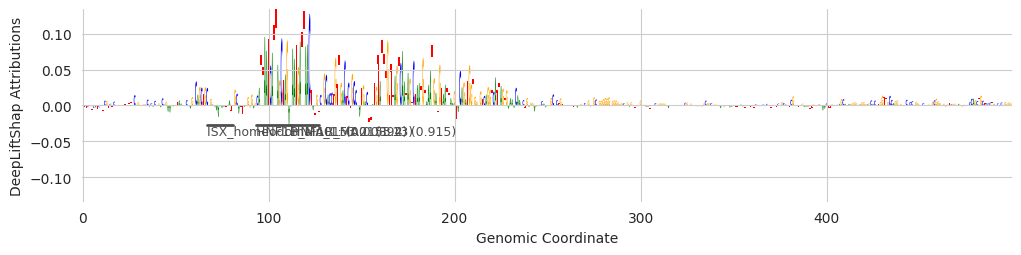

In [112]:
from tangermeme.plot import plot_logo
from matplotlib import pyplot as plt
import seaborn; seaborn.set_style('whitegrid')



seqlets_ = seqlets[seqlets['attribution'] > 0]

plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr_counts_mutated[0], ax=ax, start=seq_start, end=seq_end, annotations=seqlets_, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

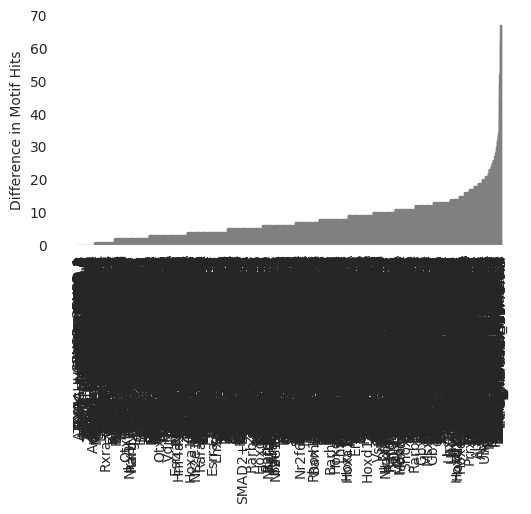

In [ ]:
plt.figure(figsize=(6, 3))
plt.bar(range(len(), hits_diff[hits_idxs], facecolor='0.5', edgecolor='0.5')
plt.ylabel("Difference in Motif Hits") 

plt.xticks(range(6), motif_names[hits_idxs], rotation=90)
sns.despine(bottom=True, left=True)
plt.show()

# DONE!

---

In [ ]:
X_ = _edit_distance_one(X[0], seq_start, seq_end)
X_.shape

torch.Size([2000, 4, 2114])

In [ ]:
np.where(X.cpu().numpy() != X_[4].cpu().numpy())  # positions of mutations

(array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))

In [114]:
count_wrapper(X), count_wrapper(X_[4:5])

RuntimeError: Input type (double) and bias type (float) should be the same

In [56]:
predict(
    count_wrapper,
    X
) - predict(
    count_wrapper,
    X_[4:5]
)

tensor([[0.]])

In [57]:
count_wrapper(X) - count_wrapper(X_[4:5])

RuntimeError: Input type (double) and bias type (float) should be the same

In [58]:
X[0, :, seq_start:seq_start+10]

tensor([[0., 0., 0., 0., 1., 0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0., 1., 0., 1., 0., 1.],
        [0., 1., 1., 1., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0',
       dtype=torch.float64)

In [59]:
X_[7, :, seq_start:seq_start+10]

tensor([[0., 0., 0., 0., 1., 0., 0., 1., 1., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 1.],
        [0., 1., 1., 1., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0',
       dtype=torch.float64)

In [60]:
# Clear cuda cache
import gc
gc.collect()
torch.cuda.empty_cache()

In [61]:
y_hat = []
y_hat_ = predict(
    count_wrapper,
    X_, 
    verbose=True
)
y_hat.append(y_hat_)
y_hat[0][4]

100%|██████████| 63/63 [00:01<00:00, 31.97it/s]


tensor([8.7076])

In [62]:
predict(
    count_wrapper,
    X_[4:5], 
    verbose=True
)

100%|██████████| 1/1 [00:00<00:00, 466.97it/s]


tensor([[8.7073]])

In [63]:
count_wrapper(X_[:32])[4]

RuntimeError: Input type (double) and bias type (float) should be the same

In [64]:
count_wrapper(X_[4:5])

RuntimeError: Input type (double) and bias type (float) should be the same

In [65]:
y_hat[0][4]

tensor([8.7076])

In [568]:
y_hat[0].shape

torch.Size([2000, 1])

In [575]:
y0 - y_hat[0][:10]

tensor([[ 0.0187],
        [ 0.0137],
        [ 0.0099],
        [-0.0290],
        [-0.0003],
        [ 0.0101],
        [ 0.0024],
        [-0.0002],
        [-0.0003],
        [ 0.0102]])

In [469]:
y_hat = torch.stack(y_hat).reshape(X.shape[0], X.shape[1], seq_end-seq_start)

In [470]:
y_hat

tensor([[[8.6886, 8.6936, 8.6974,  ..., 8.7338, 8.6904, 8.6948],
         [8.7076, 8.7271, 8.7291,  ..., 8.7016, 8.7076, 8.7076],
         [8.6790, 8.7076, 8.7076,  ..., 8.7076, 8.8274, 8.6888],
         [8.6644, 8.6843, 8.7807,  ..., 8.7172, 8.6851, 8.6863]]])

In [530]:
res = saturation_mutagenesis(
    count_wrapper,
    X,
    start=seq_start,
    end=seq_end,
    raw_outputs=True,
    #hypothetical=True,
    verbose=True,
)

100%|██████████| 63/63 [00:02<00:00, 31.13it/s]


In [ ]:
res[1][0]

torch.Size([1, 4, 500, 1])

In [332]:
res = saturation_mutagenesis(
    count_wrapper,
    X,
    #start=seq_start,
    #end=seq_end,
    raw_outputs=True,
    #hypothetical=True,
    verbose=True,
)

100%|██████████| 265/265 [00:08<00:00, 31.46it/s]


In [335]:
X[0, :, :]

tensor([[0, 0, 0,  ..., 1, 0, 0],
        [0, 0, 0,  ..., 0, 1, 0],
        [0, 0, 1,  ..., 0, 0, 1],
        [1, 1, 0,  ..., 0, 0, 0]], dtype=torch.int8)

In [340]:
res[0]

tensor([[8.7073]])

In [338]:
res[1].shape

torch.Size([1, 4, 2114, 1])

In [342]:
res[1]

tensor([[[[8.7076],
          [8.7076],
          [8.7076],
          ...,
          [8.7076],
          [8.7076],
          [8.7076]],

         [[8.7076],
          [8.7076],
          [8.7076],
          ...,
          [8.7076],
          [8.7076],
          [8.7076]],

         [[8.7076],
          [8.7076],
          [8.7076],
          ...,
          [8.7076],
          [8.7076],
          [8.7076]],

         [[8.7076],
          [8.7076],
          [8.7076],
          ...,
          [8.7073],
          [8.7073],
          [8.7073]]]])

In [42]:
window = 200
seq_center = 2114 // 2
plot_center = 1050
offset = plot_center - seq_center
seq_start = seq_center - window // 2
seq_end = seq_center + window // 2
target_start = (target_len // 2 - window // 2) + offset
target_end = (target_len // 2 + window // 2) + offset

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

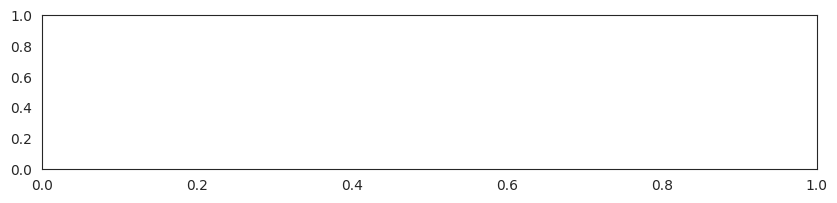

In [43]:
plt.figure(figsize=(10, 2))
ax = plt.subplot(111)
plot_logo(res[0, :, seq_start:seq_end], ax=ax)

plt.xlabel("Genomic Position")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [18]:
revcomp_original_seq = sp.reverse_complement(original_seq, sp.DNA)
revcomp_mutated_seq = sp.reverse_complement(mutated_seq, sp.DNA)
original_seq_onehot = np.expand_dims(sp.ohe(original_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
revcomp_original_seq_onehot = np.expand_dims(sp.ohe(revcomp_original_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
revcomp_mutated_seq_onehot = np.expand_dims(sp.ohe(revcomp_mutated_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
original_seq_onehot.shape, revcomp_original_seq_onehot.shape, mutated_seq_onehot.shape, revcomp_mutated_seq_onehot.shape

((1, 4, 2114), (1, 4, 2114), (1, 4, 2114), (1, 4, 2114))

In [78]:
fwd_original_profile, fwd_original_counts = predict(model, torch.tensor(original_seq_onehot).float().cuda())
rev_original_profile, rev_original_counts = predict(model, torch.tensor(revcomp_original_seq_onehot).float().cuda())
fwd_original_counts = np.squeeze(np.exp(fwd_original_counts.cpu().detach().numpy()))
rev_original_counts = np.squeeze(np.exp(rev_original_counts.cpu().detach().numpy()))
fwd_original_profile = np.squeeze(torch.exp(log_softmax_profile(fwd_original_profile)).cpu().detach().numpy())
rev_original_profile = np.squeeze(torch.exp(log_softmax_profile(rev_original_profile)).cpu().detach().numpy())
original_counts = (fwd_original_counts + rev_original_counts) / 2
original_profile = (fwd_original_profile + rev_original_profile) / 2

fwd_mutated_profile, fwd_mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
rev_mutated_profile, rev_mutated_counts = predict(model, torch.tensor(revcomp_mutated_seq_onehot).float().cuda())
fwd_mutated_counts = np.squeeze(np.exp(fwd_mutated_counts.cpu().detach().numpy()))
rev_mutated_counts = np.squeeze(np.exp(rev_mutated_counts.cpu().detach().numpy()))
fwd_mutated_profile = np.squeeze(torch.exp(log_softmax_profile(fwd_mutated_profile)).cpu().detach().numpy())
rev_mutated_profile = np.squeeze(torch.exp(log_softmax_profile(rev_mutated_profile)).cpu().detach().numpy())
mutated_counts = (fwd_mutated_counts + rev_mutated_counts) / 2
mutated_profile = (fwd_mutated_profile + rev_mutated_profile) / 2

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original counts: 2247.2788675435495
mutated counts: 5752.601375189747


In [79]:
original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

((1000,), (1000,))

# Attribution

In [73]:
dtype = torch.float64
count_wrapper = CountWrapper(ControlWrapper(model)).cuda().eval()

In [69]:
# Get attribution scores for the original sequence
X_attr_counts = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(original_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)

100%|██████████| 20/20 [02:29<00:00,  7.46s/it]


In [ ]:
# Get attribution scores for the mutated sequence
X_attr_counts_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)

100%|██████████| 20/20 [00:06<00:00,  3.12it/s]


# Plot

In [127]:
seq_len = 2114
target_len = 1000

In [128]:
chrom = "chr4"
start = 84432784
end = 84434897

In [129]:
window = 200
seq_center = 2114 // 2
plot_center = 1050
offset = plot_center - seq_center
offset

-7

In [130]:
seq_start = seq_center - window // 2
seq_end = seq_center + window // 2
target_start = (target_len // 2 - window // 2) + offset
target_end = (target_len // 2 + window // 2) + offset
ref_start = start + seq_start
ref_end = start + seq_end
seq_start, seq_end, target_start, target_end, ref_start, ref_end

(957, 1157, 393, 593, 84433741, 84433941)

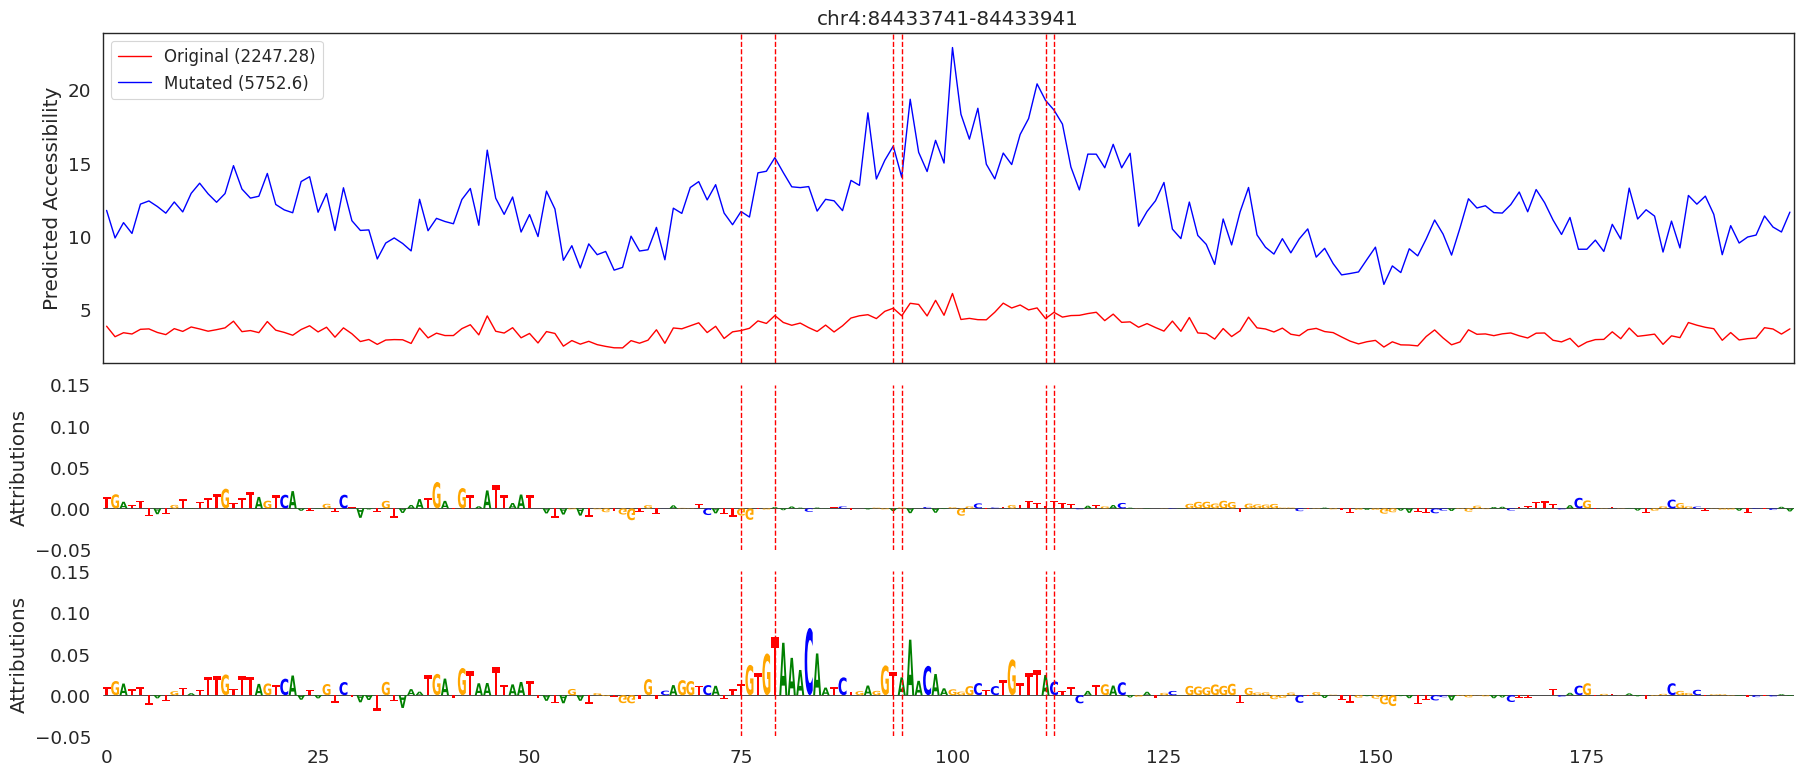

In [131]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, window), original_pred[target_start:target_end], color='r', linewidth=1, label=f"Original ({round(original_counts, 2)})")
    axes[0].plot(range(0, window), mutated_pred[target_start:target_end], color='b', linewidth=1, label=f"Mutated ({round(mutated_counts, 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_counts[0, :, seq_start:seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_counts_mutated[0, :, seq_start:seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - seq_start
        axes[0].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig(f"{path_out}/NKX6-1_predicted_FOXA_optimization_{window}.pdf", dpi=300)
